In [190]:
from typing import List
import numpy as np
import stim
import networkx as nx
from stimcirq import stim_circuit_to_cirq_circuit, cirq_circuit_to_stim_circuit
import cirq
import openfermion as of
from encoded.code_extension import encoding_unitary_for_new_stabilizer
from encoded.utils import cirq_pauli_string_to_stim, stim_pauli_string_to_cirq
from encoded.diagonalizing_circuit import get_measurement_circuit

In [191]:
generators = [
    stim.PauliString("ZIZII"),
    stim.PauliString("IZIZI"),
    stim.PauliString("IZZIZ")
]

In [192]:
for gi in generators:
    for gj in generators:
        assert gi.commutes(gj)

In [193]:
errors = [
    stim.PauliString("XIII"),
    stim.PauliString("IXII"),
    stim.PauliString("IIXI"),
    stim.PauliString("IIIX"),
]

In [194]:
number_true = 0
number_checked = 0
for i, ei in enumerate(errors):
    for j in range(i):
        number_checked += 1
        ej = errors[j]
        e = ei * ej
        commutators = []
        for generator in generators:
            comm = e.commutes(generator)
            commutators.append(comm)
        has_anticommuting_operator = any([not b for b in commutators])
        if has_anticommuting_operator:
            number_true += 1
        else:
            print(f"{ei} * {ej} = {e}, {commutators} {has_anticommuting_operator} ")
print(f"{number_true}/{number_checked} operators anticommute.")

6/6 operators anticommute.


## Encoding circuit

In [195]:
tableau = stim.Tableau.from_stabilizers(generators, allow_underconstrained=True)
encoding_circuit = tableau.to_circuit()
print(encoding_circuit)

CX 1 0 2 0 3 0 4 0 1 2 3 1 3 2 4 2


In [196]:
for gen in generators:
    print(gen.before(encoding_circuit))

+Z____
+_Z___
+__Z__


In [197]:
encoding_circuit_cirq = stim_circuit_to_cirq_circuit(encoding_circuit)

## Logical fermionic operators

In [198]:
logical_ops_fermi = [
    of.FermionOperator("1^ 1"),
    of.FermionOperator("2^ 2"),
    of.FermionOperator("3^ 3"),
    of.FermionOperator("4^ 4"),
    of.FermionOperator("1^ 3"),
    of.FermionOperator("3^ 1"),
    of.FermionOperator("2^ 4"),
    of.FermionOperator("4^ 2"),
]

In [199]:
logical_ops_qubop = [of.transforms.jordan_wigner(lop) for lop in logical_ops_fermi]
logical_ops_cirq = [of.transforms.qubit_operator_to_pauli_sum(lop) for lop in logical_ops_qubop]

In [200]:
def conjugate_psum_with_circuit(psum: cirq.PauliSum, circuit: cirq.Circuit) -> cirq.PauliSum:
    new_pstrings = []
    for pstring in psum:
        new_pstrings.append(pstring.after(circuit))
    return cirq.PauliSum.from_pauli_strings(new_pstrings)

In [201]:
for lop in logical_ops_cirq:
    print(conjugate_psum_with_circuit(lop, encoding_circuit_cirq))

0.500*I-0.500*Z(q(1))*Z(q(3))
0.500*I-0.500*Z(q(1))*Z(q(2))*Z(q(4))
0.500*I-0.500*Z(q(3))
0.500*I-0.500*Z(q(4))
-0.250j*Z(q(2))*Y(q(3))*Z(q(4))-0.250*Z(q(2))*X(q(3))*Z(q(4))+0.250*Z(q(1))*Z(q(2))*X(q(3))*Z(q(4))+0.250j*Z(q(1))*Z(q(2))*Y(q(3))*Z(q(4))
0.250j*Z(q(2))*Y(q(3))*Z(q(4))+0.250*Z(q(1))*Z(q(2))*X(q(3))*Z(q(4))-0.250*Z(q(2))*X(q(3))*Z(q(4))-0.250j*Z(q(1))*Z(q(2))*Y(q(3))*Z(q(4))
-0.250j*Z(q(1))*Z(q(2))*Z(q(3))*Y(q(4))-0.250*Z(q(1))*Z(q(2))*Z(q(3))*X(q(4))+0.250*Z(q(3))*X(q(4))+0.250j*Z(q(3))*Y(q(4))
0.250j*Z(q(1))*Z(q(2))*Z(q(3))*Y(q(4))+0.250*Z(q(3))*X(q(4))-0.250*Z(q(1))*Z(q(2))*Z(q(3))*X(q(4))-0.250j*Z(q(3))*Y(q(4))


## Correcting phase flip errors

If we turn every $Z$ in the stabilizers into an $X$, we would get a code to correct phase-flip errors. Using the framework of entanglement-assisted (EA) codes, we could combine these into a code that corrects all single-qubit errors on the first four qubits. Suppose we have two Abelian stabilizer groups, $G_1$ and $G_2$, and that $G_1 \cup G_2$ is not necessarily Abelian.
1. Make a graph where each node is a generator of $G_1$ or $G_2$.
2. For each pair of $g \in G_1$ and $g' \in G_2$, add an edges to the graph if $[g, g'] \neq 0$.
3. For each edge in the graph, add an $X$ to $g$ and a $Z$ to $g_2$ (or vice-versa), where the new Pauli acts on a new, noiseless qubit.

In [202]:
x_generators = []
for gen in generators:
    new_paulis = []
    # Convert every Z to an X.
    for p in gen:
        if p == 3:
            new_paulis.append(1)
        else:
            new_paulis.append(p)
    x_generators.append(stim.PauliString(new_paulis))

for gen in x_generators:
    print(gen)

+X_X__
+_X_X_
+_XX_X


In [203]:
graph = nx.Graph()
for gen in generators + x_generators:
    graph.add_node(str(gen))

In [204]:
for gen1 in generators:
    for gen2 in x_generators:
        if not gen1.commutes(gen2):
            graph.add_edge(str(gen1), str(gen2))

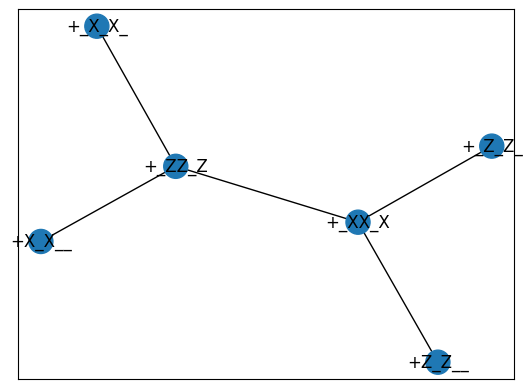

In [205]:
nx.display(graph)

We now have six generators. The original "code" has four physical qubits and two stabilizers, so it encodes two logical qubits. To encode two logical qubits with six generators, we need eight physical qubits. We can add Paulis to three new qubits in order to resolve anticommutations in the graph above.

In [206]:
ea_generators = [
    stim.PauliString("ZIZIIZII"),
    stim.PauliString("IZIZIZII"),
    stim.PauliString("IZZIZIZZ"),
    stim.PauliString("XIXIIIXI"),
    stim.PauliString("IXIXIIXI"),
    stim.PauliString("IXXIXXIX")
]

In [207]:
for gen1 in ea_generators:
    for gen2 in ea_generators:
        assert gen1.commutes(gen2), f"[{gen1}, {gen2}] != 0"